In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
listings = pd.read_csv("/content/drive/MyDrive/Data Engineering/listings.csv")
reviews = pd.read_csv("/content/drive/MyDrive/Data Engineering/reviews.csv")
calendar = pd.read_csv("/content/drive/MyDrive/Data Engineering/calendar.csv")
neighbourhoods = pd.read_csv("/content/drive/MyDrive/Data Engineering/neighbourhoods.csv")

In [ ]:
datasets = {
    "Listings": listings,
    "Reviews": reviews,
    "Calendar": calendar,
    "Neighbourhoods": neighbourhoods
}

In [ ]:
for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows × {df.shape[1]} columns")

Listings: 453 rows × 85 columns
Reviews: 27892 rows × 6 columns
Calendar: 165345 rows × 7 columns
Neighbourhoods: 16 rows × 2 columns


In [ ]:
for name, df in datasets.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)
    print(df.columns.tolist())


Listings
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_night

In [ ]:
for name, df in datasets.items():
    print("\n" + "="*50)
    print(f"{name} Data Types")
    print("="*50)

    schema = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str)
    })

    display(schema)


Listings Data Types


,Column,Data Type
id,id,int64
listing_url,listing_url,object
scrape_id,scrape_id,int64
last_scraped,last_scraped,object
source,source,object
name,name,object
description,description,object
neighborhood_overview,neighborhood_overview,float64
picture_url,picture_url,object
host_id,host_id,int64



Reviews Data Types


,Column,Data Type
listing_id,listing_id,int64
id,id,int64
date,date,object
reviewer_id,reviewer_id,int64
reviewer_name,reviewer_name,object
comments,comments,object



Calendar Data Types


,Column,Data Type
listing_id,listing_id,int64
date,date,object
available,available,object
price,price,float64
adjusted_price,adjusted_price,float64
minimum_nights,minimum_nights,int64
maximum_nights,maximum_nights,int64



Neighbourhoods Data Types


,Column,Data Type
neighbourhood_group,neighbourhood_group,float64
neighbourhood,neighbourhood,object


In [ ]:
for name, df in datasets.items():
    print(f"\n{name} Sample Records")
    display(df.head())


Listings Sample Records


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20260215064701,2026-02-15,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,https://www.airbnb.com/users/show/4621559,1462661762635155041,https://www.airbnb.com/users/profile/146266176...,Kenneth,NaN,13,1,13,0,"New York, NY",I am a real down to earth & cool person.,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/4621559/profi...,NaN,1,NaN,NaN,t,t,NaN,THIRD WARD,NaN,42.65789,-73.75370,Entire rental unit,Entire home/apt,4,1.0,1 bath,2.0,2.0,"[""Smoke alarm"", ""Kitchen"", ""Air conditioning"",...",NaN,28,1125,28,28,1125,1125,28.0,1125.0,NaN,t,0,16,46,321,2026-02-15,9,0,0,276,0,0,NaN,2014-07-01,2022-08-17,3.56,3.44,3.56,4.22,4.56,3.22,3.67,NaN,NaN,1,1,0,0,0.06
1,3820211,https://www.airbnb.com/rooms/3820211,20260215064701,2026-02-15,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,https://www.airbnb.com/users/show/19648678,1463087024016718788,https://www.airbnb.com/users/profile/146308702...,Ming,NaN,11,6,11,6,"Albany, NY","Hello! I’m a proud resident of Albany, NY, whe...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,7,NaN,NaN,t,t,NaN,SIXTH WARD,NaN,42.65222,-73.76724,Entire rental unit,Entire home/apt,3,1.0,1 bath,1.0,1.0,"[""Smoke alarm"", ""Kitchen"", ""Dishwasher"", ""Wifi...",NaN,1,1125,1,3,1125,1125,2.7,1125.0,NaN,t,0,0,26,301,2026-02-15,317,10,2,256,9,60,NaN,2014-08-15,2026-01-25,4.75,4.88,4.87,4.85,4.81,4.82,4.78,NaN,NaN,7,7,0,0,2.26
2,5651579,https://www.airbnb.com/rooms/5651579,20260215064701,2026-02-15,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",NaN,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,https://www.airbnb.com/users/show/29288920,1465431505328745177,https://www.airbnb.com/users/profile/146543150...,Gregg,NaN,10,11,10,11,"Albany, NY",I am an Albany native .I have lived in Ireland...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/29288920/prof...,NaN,2,NaN,NaN,t,t,NaN,SECOND WARD,NaN,42.64615,-73.75966,Entire rental unit,Entire home/apt,2,1.0,1 bath,0.0,2.0,"[""Smoke alarm"", ""Kitchen"", ""Wifi"", ""Shower gel...",NaN,1,1125,1,2,1125,1125,1.3,1125.0,NaN,t,18,31,35,35,2026-02-15,389,20,2,35,18,120,NaN,2015-05-08,2026-02-06,4.51,


Reviews Sample Records


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,2992450,15066586,2014-07-01,16827297,Kristen,Large apartment; nice kitchen and bathroom. Ke...
1,2992450,21810844,2014-10-24,22648856,Christopher,"This may be a little late, but just to say Ken..."
2,2992450,27434334,2015-03-04,45406,Altay,The apartment was very clean and convenient to...
3,2992450,28524578,2015-03-25,5485362,John,Kenneth was ready when I got there and arrange...
4,2992450,35913434,2015-06-23,15772025,Jennifer,We were pleased to see how 2nd Street and the ...



Calendar Sample Records


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,2992450,2026-02-15,f,NaN,NaN,28,1125
1,2992450,2026-02-16,f,NaN,NaN,28,1125
2,2992450,2026-02-17,f,NaN,NaN,28,1125
3,2992450,2026-02-18,f,NaN,NaN,28,1125
4,2992450,2026-02-19,f,NaN,NaN,28,1125



Neighbourhoods Sample Records


,neighbourhood_group,neighbourhood
0,NaN,EIGHTH WARD
1,NaN,ELEVENTH WARD
2,NaN,FIFTEENTH WARD
3,NaN,FIFTH WARD
4,NaN,FIRST WARD


In [ ]:
for name, df in datasets.items():

    numerical_cols = df.select_dtypes(
        include=["int64","float64"]
    )

    if len(numerical_cols.columns) > 0:

        print(f"\n{name} Numerical Summary")

        summary = numerical_cols.describe().T[
            ["min","max","mean"]
        ]

        display(summary)


Listings Numerical Summary


,min,max,mean
id,2.992450e+06,1.611096e+18,8.981917e+17
scrape_id,2.026022e+13,2.026022e+13,2.026022e+13
neighborhood_overview,NaN,NaN,NaN
host_id,6.490680e+05,7.395856e+08,2.505305e+08
host_profile_id,1.462518e+18,1.601568e+18,1.468835e+18
host_since,NaN,NaN,NaN
hosts_time_as_user_years,0.000000e+00,1.400000e+01,6.741722e+00
hosts_time_as_user_months,0.000000e+00,1.100000e+01,5.538631e+00
hosts_time_as_host_years,0.000000e+00,1.300000e+01,4.139073e+00
hosts_time_as_host_months,0.000000e+00,1.100000e+01,5.746137e+00



Reviews Numerical Summary


,min,max,mean
listing_id,2992450.0,1.605353e+18,3.174434e+17
id,15066586.0,1.621244e+18,8.512753e+17
reviewer_id,283.0,7.453036e+08,2.264638e+08



Calendar Numerical Summary


,min,max,mean
listing_id,2992450.0,1.611096e+18,8.981917e+17
price,NaN,NaN,NaN
adjusted_price,NaN,NaN,NaN
minimum_nights,1.0,3.650000e+02,6.809247e+00
maximum_nights,1.0,1.125000e+03,6.252845e+02



Neighbourhoods Numerical Summary


,min,max,mean
neighbourhood_group,NaN,NaN,NaN


In [ ]:
print(
    "Listings ID Unique:",
    listings["id"].is_unique
)

Listings ID Unique: True


In [ ]:
print(
    "Reviews ID Unique:",
    reviews["id"].is_unique
)

Reviews ID Unique: True


In [ ]:
calendar_pk = calendar[
    ["listing_id","date"]
].duplicated().sum()

print(
    "Duplicate Calendar Composite Keys:",
    calendar_pk
)

Duplicate Calendar Composite Keys: 0


In [ ]:
missing_reviews = (
    set(reviews["listing_id"])
    - set(listings["id"])
)

print(
    "Unmatched Review Listings:",
    len(missing_reviews)
)

Unmatched Review Listings: 0


In [ ]:
missing_calendar = (
    set(calendar["listing_id"])
    - set(listings["id"])
)

print(
    "Unmatched Calendar Listings:",
    len(missing_calendar)
)

Unmatched Calendar Listings: 0


In [ ]:
for name, df in datasets.items():

    print(f"\n{name}")

    missing = (
        df.isnull()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    display(
        missing[missing > 0]
        .to_frame("% Missing")
        .head(20)
    )


Listings


,% Missing
neighborhood_overview,100.000000
host_since,100.000000
host_acceptance_rate,100.000000
host_response_rate,100.000000
host_response_time,100.000000
host_total_listings_count,100.000000
host_verifications,100.000000
license,100.000000
instant_bookable,100.000000
calendar_updated,100.000000



Reviews


,% Missing
comments,0.028682



Calendar


,% Missing
price,100.0
adjusted_price,100.0



Neighbourhoods


,% Missing
neighbourhood_group,100.00
neighbourhood,6.25


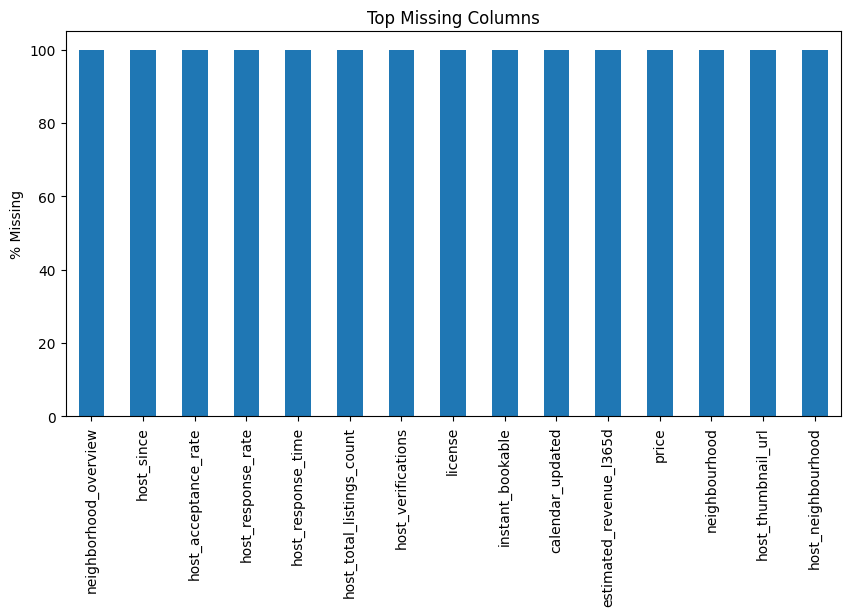

In [ ]:
import matplotlib.pyplot as plt

missing = (
    listings.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing.head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Missing Columns")
plt.ylabel("% Missing")
plt.show()

In [ ]:
for name, df in datasets.items():

    print(
        f"{name} Duplicates:",
        df.duplicated().sum()
    )

Listings Duplicates: 0
Reviews Duplicates: 0
Calendar Duplicates: 0
Neighbourhoods Duplicates: 0


In [ ]:
for name, df in datasets.items():

    cardinality = pd.DataFrame({
        "Column": df.columns,
        "Unique Values":
            [df[col].nunique()
             for col in df.columns]
    })

    print(f"\n{name}")
    display(cardinality)


Listings


,Column,Unique Values
0,id,453
1,listing_url,453
2,scrape_id,1
3,last_scraped,1
4,source,2
5,name,452
6,description,387
7,neighborhood_overview,0
8,picture_url,448
9,host_id,184



Reviews


,Column,Unique Values
0,listing_id,395
1,id,27892
2,date,3502
3,reviewer_id,23062
4,reviewer_name,7077
5,comments,27032



Calendar


,Column,Unique Values
0,listing_id,453
1,date,365
2,available,2
3,price,0
4,adjusted_price,0
5,minimum_nights,24
6,maximum_nights,194



Neighbourhoods


,Column,Unique Values
0,neighbourhood_group,0
1,neighbourhood,15
